# Notebook 06 — Customer Churn Prediction

## Objective

Membangun model machine learning untuk memprediksi kemungkinan customer
mengalami churn berdasarkan karakteristik dan perilaku customer.

## Business Context

Customer churn dapat menyebabkan kehilangan revenue dan meningkatkan biaya
akuisisi customer baru.

Model churn prediction bertujuan membantu perusahaan:

- mengidentifikasi customer yang berpotensi churn,
- menentukan prioritas retention,
- memahami faktor yang berkaitan dengan churn,
- mendukung pengambilan keputusan berbasis data.

## Target

Target prediction:

`is_churned`

- `0` = Active Customer
- `1` = Churned Customer

## Methodology

1. Load customer feature dataset
2. Validate target distribution
3. Identify potential data leakage
4. Select predictive features
5. Split data into training and testing sets
6. Build preprocessing pipeline
7. Train baseline model
8. Evaluate model performance
9. Compare candidate models
10. Analyze important features
11. Translate model results into business insights

## Important Data Leakage Considerations

The dataset contains a `segment` variable that was used during synthetic
data generation to influence the probability of churn.

Therefore, `segment` will not be used as a predictive feature.

Similarly, `business_segment` and `cluster` generated from customer
segmentation will not be used as direct churn prediction features.

`lifetime_value` will also be excluded initially because its temporal
relationship with churn is not sufficiently clear.

## Evaluation Principle

Accuracy alone will not be used as the primary evaluation metric.

Because churn detection is a classification problem, the model will be
evaluated using:

- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix

Recall is particularly important because failing to identify a customer
who will churn may result in a missed retention opportunity.

## 2. Load Customer Feature Dataset

Dataset customer-level hasil feature engineering akan digunakan sebagai
input utama untuk model churn prediction.

Dataset ini berasal dari:

`data/processed/customer_features.csv`

Pada tahap ini kita memastikan:

- dataset berhasil dimuat,
- jumlah baris sesuai dengan jumlah customer,
- target `is_churned` tersedia,
- feature hasil engineering tersedia.

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
PROCESSED_DIR = Path("../data/processed")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

FEATURE_PATH = PROCESSED_DIR / "customer_features.csv"

customer_features = pd.read_csv(FEATURE_PATH)

print("Customer churn dataset loaded.")
print("Shape:", customer_features.shape)

print("\nColumns:")
print(customer_features.columns.tolist())

Customer churn dataset loaded.
Shape: (10000, 21)

Columns:
['customer_id', 'age', 'gender', 'country', 'email_opt_in', 'has_app', 'is_churned', 'recency_days', 'frequency', 'monetary', 'total_orders', 'total_quantity', 'average_order_value', 'tenure_days', 'total_sessions', 'avg_session_duration', 'avg_pages_viewed', 'total_cart_additions', 'conversion_rate', 'bounce_rate', 'has_purchase']


## 3. Target Distribution

Sebelum melakukan training model, distribusi target `is_churned` perlu
diperiksa untuk mengetahui apakah terdapat class imbalance.

Class imbalance penting diperhatikan karena jumlah customer active dan
churned yang tidak seimbang dapat menyebabkan model terlalu fokus pada
kelas mayoritas.

Distribusi target akan digunakan sebagai dasar dalam menentukan strategi
evaluasi model.

In [6]:
target_distribution = (
    customer_features["is_churned"]
    .value_counts()
    .sort_index()
    .rename(index={
        0: "Active",
        1: "Churned",
    })
)

target_percentage = (
    customer_features["is_churned"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .rename(index={
        0: "Active",
        1: "Churned",
    })
)

target_summary = pd.DataFrame({
    "customer_count": target_distribution,
    "percentage": target_percentage,
})

print("Target distribution:")
display(target_summary)

Target distribution:


,customer_count,percentage
is_churned,,
Active,8306,83.06
Churned,1694,16.94


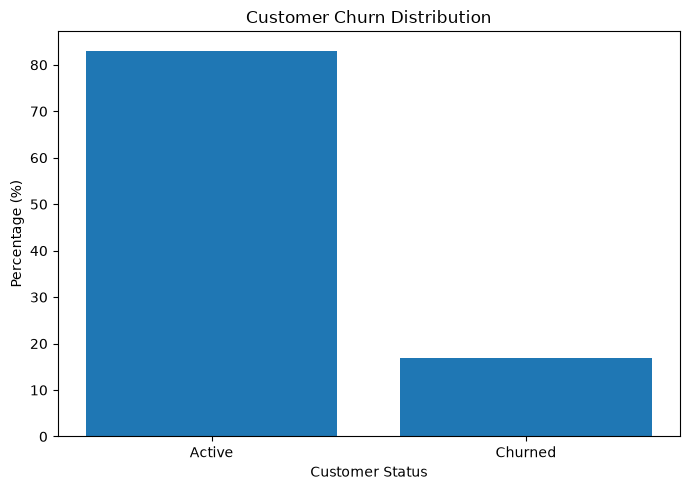

In [7]:
plt.figure(figsize=(7, 5))

plt.bar(
    target_summary.index,
    target_summary["percentage"],
)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Percentage (%)")
plt.tight_layout()
plt.show()

## 4. Data Leakage Check

Data leakage terjadi ketika model menggunakan informasi yang secara langsung
atau tidak langsung mengandung informasi mengenai target.

Pada dataset ini terdapat beberapa kolom yang perlu diperiksa secara khusus.

### Excluded Features

**`segment`**

Kolom ini tidak tersedia pada `customer_features.csv`, tetapi berdasarkan
proses pembuatan dataset, `segment` digunakan untuk menentukan probabilitas
churn. Karena itu kolom tersebut tidak boleh digunakan sebagai predictor.

**`business_segment` dan `cluster`**

Kedua feature berasal dari proses customer segmentation. Keduanya tidak
digunakan sebagai input langsung untuk model churn agar model belajar dari
karakteristik customer, bukan dari label segmentasi yang telah dibuat.

**`lifetime_value`**

Feature ini tidak digunakan pada baseline karena temporal relationship
terhadap churn belum cukup jelas. Nilainya berpotensi mengandung informasi
yang terakumulasi setelah customer mengalami churn.

### Features Used

Model akan menggunakan feature customer profile, purchase behavior,
engagement, dan tenure yang tersedia pada customer feature dataset.

`customer_id` juga tidak digunakan karena merupakan identifier, bukan
karakteristik customer.

In [8]:
excluded_features = [
    "customer_id",
    "is_churned",
]

available_features = [
    column
    for column in customer_features.columns
    if column not in excluded_features
]

print("Available predictive features:")
print(available_features)

print("\nNumber of predictive features:", len(available_features))

Available predictive features:
['age', 'gender', 'country', 'email_opt_in', 'has_app', 'recency_days', 'frequency', 'monetary', 'total_orders', 'total_quantity', 'average_order_value', 'tenure_days', 'total_sessions', 'avg_session_duration', 'avg_pages_viewed', 'total_cart_additions', 'conversion_rate', 'bounce_rate', 'has_purchase']

Number of predictive features: 19


## 5. Feature Selection

Predictive features akan dipisahkan menjadi dua kelompok:

### Numerical Features

Feature numerik akan diproses menggunakan imputation dan scaling.

Feature yang digunakan:

- age
- recency_days
- frequency
- monetary
- total_orders
- total_quantity
- average_order_value
- tenure_days
- total_sessions
- avg_session_duration
- avg_pages_viewed
- total_cart_additions
- conversion_rate
- bounce_rate

### Categorical Features

Feature kategorikal akan diproses menggunakan imputation dan one-hot encoding.

Feature yang digunakan:

- gender
- country
- email_opt_in
- has_app
- has_purchase

### Target

Target:

`is_churned`

`customer_id` tidak digunakan karena hanya merupakan identifier.

`segment`, `business_segment`, `cluster`, dan `lifetime_value` tidak digunakan
karena pertimbangan data leakage dan temporal validity.

In [9]:
numeric_features = [
    "age",
    "recency_days",
    "frequency",
    "monetary",
    "total_orders",
    "total_quantity",
    "average_order_value",
    "tenure_days",
    "total_sessions",
    "avg_session_duration",
    "avg_pages_viewed",
    "total_cart_additions",
    "conversion_rate",
    "bounce_rate",
]

categorical_features = [
    "gender",
    "country",
    "email_opt_in",
    "has_app",
    "has_purchase",
]

target_column = "is_churned"

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Total predictive features:", len(numeric_features) + len(categorical_features))
print("Target:", target_column)

Numerical features: 14
Categorical features: 5
Total predictive features: 19
Target: is_churned


In [10]:
selected_features = numeric_features + categorical_features

print("\nFeature validation")
print("=" * 40)

print(
    "Missing selected features:",
    [
        column
        for column in selected_features
        if column not in customer_features.columns
    ],
)

print(
    "Unexpected target in features:",
    target_column in selected_features,
)

print(
    "Duplicate feature names:",
    len(selected_features) != len(set(selected_features)),
)


Feature validation
Missing selected features: []
Unexpected target in features: False
Duplicate feature names: False


## 6. Train-Test Split

Dataset akan dibagi menjadi:

- 80% training data
- 20% testing data

Stratified splitting digunakan agar proporsi customer active dan churned
tetap terjaga pada training dan testing set.

Testing data tidak akan digunakan selama proses training dan preprocessing
model. Dataset ini hanya digunakan untuk evaluasi akhir model.

In [11]:
from sklearn.model_selection import train_test_split

X = customer_features[selected_features].copy()
y = customer_features[target_column].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Train-test split completed.")

print("\nDataset shape:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTarget distribution:")
print("Training:")
display(
    y_train.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .rename(index={
        0: "Active",
        1: "Churned",
    })
)

print("Testing:")
display(
    y_test.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .rename(index={
        0: "Active",
        1: "Churned",
    })
)

Train-test split completed.

Dataset shape:
X_train: (8000, 19)
X_test : (2000, 19)
y_train: (8000,)
y_test : (2000,)

Target distribution:
Training:


is_churned
Active    83.06
Churned   16.94
Name: proportion, dtype: float64

Testing:


is_churned
Active    83.05
Churned   16.95
Name: proportion, dtype: float64

## 7. Preprocessing Pipeline

Numerical dan categorical features membutuhkan preprocessing yang berbeda.

### Numerical Features

Tahapan:

1. Missing values diisi menggunakan median.
2. Feature distandardisasi menggunakan `StandardScaler`.

Median digunakan untuk menangani missing values karena beberapa customer
tidak memiliki completed transaction sehingga `recency_days` bernilai NaN.

### Categorical Features

Tahapan:

1. Missing values diisi menggunakan nilai yang paling sering muncul.
2. Categorical values diubah menjadi numerical representation menggunakan
   One-Hot Encoding.

### Data Leakage Prevention

Preprocessing akan ditempatkan di dalam `Pipeline` dan `ColumnTransformer`.

Dengan pendekatan ini, parameter preprocessing hanya dipelajari dari
training data dan kemudian diterapkan ke testing data.

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features,
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features,
        ),
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [13]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print("Preprocessing validation completed.")
print("Transformed X_train shape:", X_train_transformed.shape)
print("Transformed X_test shape :", X_test_transformed.shape)

print(
    "Missing values in transformed X_train:",
    np.isnan(X_train_transformed).sum(),
)

print(
    "Missing values in transformed X_test:",
    np.isnan(X_test_transformed).sum(),
)

Preprocessing validation completed.
Transformed X_train shape: (8000, 34)
Transformed X_test shape : (2000, 34)
Missing values in transformed X_train: 0
Missing values in transformed X_test: 0


## 8. Baseline Model — Logistic Regression

Logistic Regression digunakan sebagai baseline classification model.

Tujuan baseline bukan langsung mendapatkan model terbaik, tetapi membuat
titik pembanding untuk mengevaluasi apakah model yang lebih kompleks
memberikan peningkatan performa yang berarti.

Model akan menggunakan preprocessing pipeline yang telah dibuat sebelumnya.

Class imbalance ditangani menggunakan `class_weight="balanced"` sehingga
model memberikan perhatian yang lebih seimbang terhadap kelas Active dan
Churned.

### Evaluation Metrics

Model akan dievaluasi menggunakan:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Recall untuk kelas Churned menjadi perhatian penting karena false negative
berarti customer yang berpotensi churn tidak terdeteksi.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42,
            ),
        ),
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression baseline trained.")

Logistic Regression baseline trained.


In [15]:
y_pred = logistic_model.predict(X_test)
y_proba = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions generated.")
print("Prediction shape:", y_pred.shape)
print("Probability shape:", y_proba.shape)

Predictions generated.
Prediction shape: (2000,)
Probability shape: (2000,)


## 9. Baseline Model Evaluation

Baseline Logistic Regression akan dievaluasi menggunakan beberapa metrik
klasifikasi.

### Metrics

- **Accuracy** — proporsi seluruh prediksi yang benar.
- **Precision** — proporsi customer yang diprediksi churn dan benar-benar
  churn.
- **Recall** — proporsi customer churn yang berhasil dideteksi model.
- **F1-score** — harmonic mean antara precision dan recall.
- **ROC-AUC** — kemampuan model membedakan customer active dan churned
  berdasarkan probabilitas prediksi.

Dalam konteks churn prediction, Recall untuk kelas Churned menjadi metrik
penting karena false negative berarti customer yang berpotensi churn tidak
terdeteksi.

In [16]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    pos_label=1,
)

recall = recall_score(
    y_test,
    y_pred,
    pos_label=1,
)

f1 = f1_score(
    y_test,
    y_pred,
    pos_label=1,
)

roc_auc = roc_auc_score(
    y_test,
    y_proba,
)

baseline_metrics = pd.DataFrame({
    "metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
    ],
    "score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
    ],
})

print("Baseline Logistic Regression Metrics:")
display(baseline_metrics)

Baseline Logistic Regression Metrics:


,metric,score
0,Accuracy,0.60
1,Precision,0.25
2,Recall,0.66
3,F1-score,0.36
4,ROC-AUC,0.67


In [17]:
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Active",
            "Churned",
        ],
    )
)

Classification Report:
              precision    recall  f1-score   support

      Active       0.89      0.59      0.71      1661
     Churned       0.25      0.66      0.36       339

    accuracy                           0.60      2000
   macro avg       0.57      0.62      0.53      2000
weighted avg       0.78      0.60      0.65      2000



In [18]:
cm = confusion_matrix(
    y_test,
    y_pred,
)

print("Confusion Matrix:")
display(
    pd.DataFrame(
        cm,
        index=["Actual Active", "Actual Churned"],
        columns=["Predicted Active", "Predicted Churned"],
    )
)

Confusion Matrix:


,Predicted Active,Predicted Churned
Actual Active,972,689
Actual Churned,115,224


## 10. Baseline Business Interpretation

The baseline Logistic Regression model achieves a ROC-AUC of 0.67 and a
recall of 0.66 for the Churned class.

The model successfully identifies 224 out of 339 churned customers in the
test set.

However, 689 active customers are incorrectly classified as churned.

This produces a relatively low precision of 0.25.

From a business perspective, the baseline model is useful as a starting
point because it can identify a substantial proportion of churned customers.

However, the high number of false positives indicates that the model still
needs improvement before being used for targeted retention campaigns.

The next step is to compare the baseline against a stronger tree-based
classification model and determine whether predictive performance can be
improved.

## 11. Confusion Matrix Visualization

Confusion matrix digunakan untuk melihat distribusi prediksi model pada
empat kategori:

- True Positive
- True Negative
- False Positive
- False Negative

Visualisasi membantu memahami jenis kesalahan yang dilakukan model.

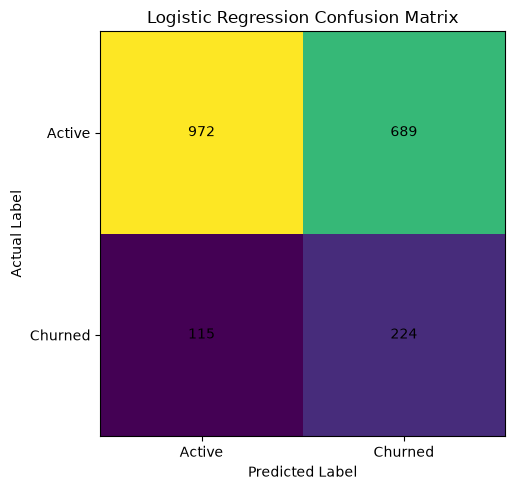

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.imshow(cm)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1],
    ["Active", "Churned"],
)

plt.yticks(
    [0, 1],
    ["Active", "Churned"],
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
        )

plt.tight_layout()
plt.show()

## 12. Random Forest Model

Random Forest digunakan sebagai model pembanding terhadap baseline
Logistic Regression.

Random Forest merupakan ensemble model berbasis decision tree yang mampu
menangkap hubungan non-linear dan interaksi antar fitur.

Model akan menggunakan preprocessing yang sama dengan baseline agar
perbandingan dilakukan secara konsisten.

### Objective

Membandingkan apakah Random Forest dapat meningkatkan performa prediksi
churn, khususnya:

- Recall
- F1-score
- ROC-AUC

Model juga menggunakan `class_weight="balanced"` untuk membantu menangani
ketidakseimbangan antara customer Active dan Churned.

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=None,
                min_samples_split=5,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

random_forest_model.fit(
    X_train,
    y_train,
)

print("Random Forest model trained.")

Random Forest model trained.


## 13. Random Forest Prediction and Evaluation

Random Forest akan menghasilkan prediksi kelas dan probabilitas churn
pada test dataset.

Evaluasi menggunakan metrik yang sama dengan baseline Logistic Regression
agar performa kedua model dapat dibandingkan secara konsisten.

Metrics yang digunakan:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

In [21]:
y_pred_rf = random_forest_model.predict(X_test)

y_proba_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest predictions generated.")
print("Prediction shape:", y_pred_rf.shape)
print("Probability shape:", y_proba_rf.shape)

Random Forest predictions generated.
Prediction shape: (2000,)
Probability shape: (2000,)


## 14. Random Forest Model Evaluation

Random Forest dievaluasi menggunakan metrik yang sama dengan Logistic
Regression.

Hasil evaluasi akan digunakan untuk mengetahui apakah Random Forest
memberikan peningkatan performa dibandingkan baseline.

Fokus utama evaluasi:

- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix

In [22]:
accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf,
)

precision_rf = precision_score(
    y_test,
    y_pred_rf,
    pos_label=1,
)

recall_rf = recall_score(
    y_test,
    y_pred_rf,
    pos_label=1,
)

f1_rf = f1_score(
    y_test,
    y_pred_rf,
    pos_label=1,
)

roc_auc_rf = roc_auc_score(
    y_test,
    y_proba_rf,
)

random_forest_metrics = pd.DataFrame({
    "metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
    ],
    "score": [
        accuracy_rf,
        precision_rf,
        recall_rf,
        f1_rf,
        roc_auc_rf,
    ],
})

print("Random Forest Metrics:")
display(random_forest_metrics)

Random Forest Metrics:


,metric,score
0,Accuracy,0.77
1,Precision,0.27
2,Recall,0.20
3,F1-score,0.23
4,ROC-AUC,0.65


In [23]:
print("Random Forest Classification Report:")

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=[
            "Active",
            "Churned",
        ],
    )
)

Random Forest Classification Report:
              precision    recall  f1-score   support

      Active       0.85      0.89      0.87      1661
     Churned       0.27      0.20      0.23       339

    accuracy                           0.77      2000
   macro avg       0.56      0.55      0.55      2000
weighted avg       0.75      0.77      0.76      2000



In [24]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf,
)

print("Random Forest Confusion Matrix:")

display(
    pd.DataFrame(
        cm_rf,
        index=[
            "Actual Active",
            "Actual Churned",
        ],
        columns=[
            "Predicted Active",
            "Predicted Churned",
        ],
    )
)

Random Forest Confusion Matrix:


,Predicted Active,Predicted Churned
Actual Active,1478,183
Actual Churned,270,69


## 15. Model Comparison

Logistic Regression dan Random Forest dibandingkan menggunakan test dataset
yang sama.

Perbandingan dilakukan berdasarkan:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Accuracy tidak dijadikan satu-satunya dasar pemilihan model karena dataset
memiliki class imbalance, dengan jumlah customer Active jauh lebih besar
daripada customer Churned.

Untuk business use case churn prediction, Recall, F1-score, dan ROC-AUC
mendapat perhatian lebih besar karena model perlu mendeteksi customer yang
berpotensi churn.

In [25]:
model_comparison = pd.DataFrame({
    "metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
    ],
    "Logistic Regression": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
    ],
    "Random Forest": [
        accuracy_rf,
        precision_rf,
        recall_rf,
        f1_rf,
        roc_auc_rf,
    ],
})

print("Model Performance Comparison:")
display(model_comparison)

Model Performance Comparison:


,metric,Logistic Regression,Random Forest
0,Accuracy,0.60,0.77
1,Precision,0.25,0.27
2,Recall,0.66,0.20
3,F1-score,0.36,0.23
4,ROC-AUC,0.67,0.65


## 16. Logistic Regression Feature Interpretation

Logistic Regression dapat digunakan untuk melihat hubungan antara fitur
dengan probabilitas churn melalui koefisien model.

Koefisien positif menunjukkan bahwa peningkatan nilai fitur atau keberadaan
kategori tersebut berkaitan dengan probabilitas churn yang lebih tinggi.

Koefisien negatif menunjukkan hubungan dengan probabilitas churn yang lebih
rendah.

Feature interpretation digunakan untuk membantu menerjemahkan hasil model
menjadi business insight.

Interpretasi ini menunjukkan hubungan prediktif pada dataset dan tidak boleh
langsung dianggap sebagai hubungan sebab-akibat.

In [26]:
feature_names = (
    logistic_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    logistic_model
    .named_steps["classifier"]
    .coef_[0]
)

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
})

feature_importance["abs_coefficient"] = (
    feature_importance["coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "abs_coefficient",
    ascending=False,
).reset_index(drop=True)

print("Top predictive features:")
display(
    feature_importance.head(15)
)

Top predictive features:


,feature,coefficient,abs_coefficient
0,categorical__country_JP,0.39,0.39
1,categorical__gender_Non-binary,-0.31,0.31
2,numeric__total_sessions,-0.30,0.30
3,categorical__country_MX,-0.28,0.28
4,categorical__country_IN,-0.16,0.16
5,categorical__gender_M,0.15,0.15
6,categorical__country_BR,0.15,0.15
7,categorical__has_app_0,-0.14,0.14
8,numeric__total_orders,-0.13,0.13
9,numeric__frequency,-0.13,0.13


## 17. Logistic Regression Feature Coefficients

Visualisasi berikut menunjukkan fitur dengan koefisien terbesar berdasarkan
nilai absolutnya.

- Koefisien positif menunjukkan hubungan dengan probabilitas churn yang
  lebih tinggi.
- Koefisien negatif menunjukkan hubungan dengan probabilitas churn yang
  lebih rendah.

Visualisasi ini digunakan untuk membantu interpretasi model dan
menghubungkan hasil machine learning dengan business insight.

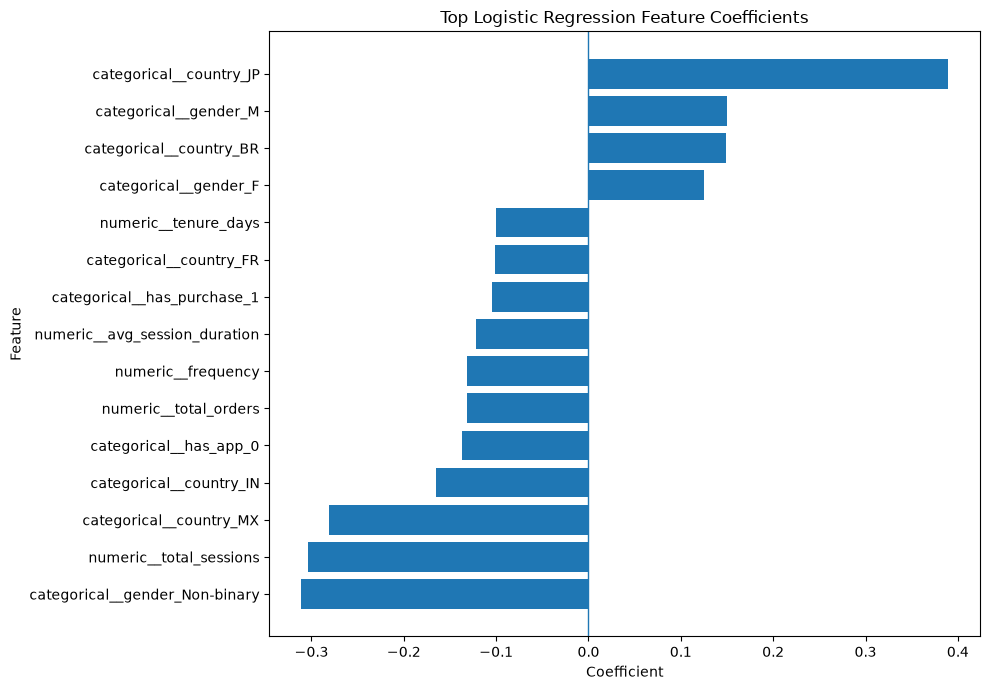

In [27]:
top_features = (
    feature_importance
    .head(15)
    .sort_values("coefficient")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["coefficient"],
)

plt.axvline(
    0,
    linewidth=1,
)

plt.title(
    "Top Logistic Regression Feature Coefficients"
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 18. Feature Refinement

Beberapa fitur memiliki informasi yang sangat berdekatan secara konseptual.

`frequency` dan `total_orders` sama-sama merepresentasikan jumlah transaksi
completed yang dilakukan oleh customer.

Untuk mengurangi redundansi fitur dan membuat model lebih mudah
diinterpretasikan, `total_orders` akan dikeluarkan dari kandidat model.

Fitur demografis dan geografis tetap dipertahankan pada tahap ini agar
perbandingan dilakukan secara objektif dan hasilnya dapat dievaluasi.

Feature refinement dilakukan sebelum final model selection.

In [30]:
refined_numeric_features = [
    "age",
    "recency_days",
    "frequency",
    "monetary",
    "total_quantity",
    "average_order_value",
    "tenure_days",
    "total_sessions",
    "avg_session_duration",
    "avg_pages_viewed",
    "total_cart_additions",
    "conversion_rate",
    "bounce_rate",
]

refined_categorical_features = [
    "gender",
    "country",
    "email_opt_in",
    "has_app",
    "has_purchase",
]

refined_features = (
    refined_numeric_features
    + refined_categorical_features
)

print("Feature refinement completed.")

print(
    "Original feature count:",
    len(selected_features),
)

print(
    "Refined feature count:",
    len(refined_features),
)

print(
    "Removed features:",
    sorted(
        set(selected_features) - set(refined_features)
    ),
)

Feature refinement completed.
Original feature count: 19
Refined feature count: 18
Removed features: ['total_orders']


## 19. Refined Preprocessing Pipeline

Preprocessing pipeline dibuat kembali menggunakan refined features.

Pipeline tetap menggunakan:

- Median imputation dan StandardScaler untuk numerical features.
- Most-frequent imputation dan OneHotEncoder untuk categorical features.

Pipeline ini memastikan preprocessing hanya dipelajari dari training data
dan kemudian diterapkan ke test data tanpa data leakage.

Hasil preprocessing akan digunakan untuk melatih Logistic Regression
versi refined.

In [31]:
refined_numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

refined_categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)

refined_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            refined_numeric_transformer,
            refined_numeric_features,
        ),
        (
            "categorical",
            refined_categorical_transformer,
            refined_categorical_features,
        ),
    ]
)

print("Refined preprocessing pipeline created.")

Refined preprocessing pipeline created.


## 20. Refined Preprocessing Validation

Refined preprocessing akan diterapkan pada training dan test dataset.

Training data digunakan untuk melakukan `fit_transform`, sedangkan test data
hanya menggunakan `transform`.

Validasi dilakukan untuk memastikan:

- jumlah fitur hasil preprocessing sesuai,
- training dan test memiliki jumlah fitur yang sama,
- tidak terdapat missing value setelah preprocessing.

In [32]:
X_train_refined = X_train[refined_features].copy()
X_test_refined = X_test[refined_features].copy()

X_train_refined_transformed = (
    refined_preprocessor.fit_transform(
        X_train_refined
    )
)

X_test_refined_transformed = (
    refined_preprocessor.transform(
        X_test_refined
    )
)

print("Refined preprocessing validation completed.")

print(
    "Transformed X_train shape:",
    X_train_refined_transformed.shape,
)

print(
    "Transformed X_test shape:",
    X_test_refined_transformed.shape,
)

print(
    "Missing values in transformed X_train:",
    np.isnan(
        X_train_refined_transformed
    ).sum(),
)

print(
    "Missing values in transformed X_test:",
    np.isnan(
        X_test_refined_transformed
    ).sum(),
)

Refined preprocessing validation completed.
Transformed X_train shape: (8000, 33)
Transformed X_test shape: (2000, 33)
Missing values in transformed X_train: 0
Missing values in transformed X_test: 0


## 21. Refined Logistic Regression Model

Logistic Regression akan dilatih kembali menggunakan refined feature set.

Model menggunakan preprocessing pipeline yang telah divalidasi pada tahap
sebelumnya.

Model ini kemudian akan dibandingkan dengan baseline Logistic Regression
untuk mengetahui dampak penghapusan fitur `total_orders`.

Class weighting tetap digunakan karena distribusi target tidak seimbang.

In [33]:
refined_logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            refined_preprocessor,
        ),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42,
            ),
        ),
    ]
)

refined_logistic_model.fit(
    X_train_refined,
    y_train,
)

print("Refined Logistic Regression model trained.")

Refined Logistic Regression model trained.


## 22. Refined Logistic Regression Evaluation

Refined Logistic Regression dievaluasi menggunakan test dataset yang sama
seperti baseline.

Tujuannya adalah mengetahui apakah penghapusan fitur `total_orders` yang
memiliki informasi serupa dengan `frequency` memberikan perubahan terhadap
performa model.

Metrik yang digunakan:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

In [34]:
y_pred_refined = refined_logistic_model.predict(
    X_test_refined
)

y_proba_refined = (
    refined_logistic_model
    .predict_proba(X_test_refined)[:, 1]
)

accuracy_refined = accuracy_score(
    y_test,
    y_pred_refined,
)

precision_refined = precision_score(
    y_test,
    y_pred_refined,
    pos_label=1,
)

recall_refined = recall_score(
    y_test,
    y_pred_refined,
    pos_label=1,
)

f1_refined = f1_score(
    y_test,
    y_pred_refined,
    pos_label=1,
)

roc_auc_refined = roc_auc_score(
    y_test,
    y_proba_refined,
)

refined_metrics = pd.DataFrame({
    "metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
    ],
    "score": [
        accuracy_refined,
        precision_refined,
        recall_refined,
        f1_refined,
        roc_auc_refined,
    ],
})

print("Refined Logistic Regression Metrics:")
display(refined_metrics)

Refined Logistic Regression Metrics:


,metric,score
0,Accuracy,0.60
1,Precision,0.25
2,Recall,0.66
3,F1-score,0.36
4,ROC-AUC,0.67


In [35]:
print("Refined Logistic Regression Classification Report:")

print(
    classification_report(
        y_test,
        y_pred_refined,
        target_names=[
            "Active",
            "Churned",
        ],
    )
)

Refined Logistic Regression Classification Report:
              precision    recall  f1-score   support

      Active       0.89      0.59      0.71      1661
     Churned       0.25      0.66      0.36       339

    accuracy                           0.60      2000
   macro avg       0.57      0.62      0.53      2000
weighted avg       0.78      0.60      0.65      2000



In [36]:
cm_refined = confusion_matrix(
    y_test,
    y_pred_refined,
)

print("Refined Logistic Regression Confusion Matrix:")

display(
    pd.DataFrame(
        cm_refined,
        index=[
            "Actual Active",
            "Actual Churned",
        ],
        columns=[
            "Predicted Active",
            "Predicted Churned",
        ],
    )
)

Refined Logistic Regression Confusion Matrix:


,Predicted Active,Predicted Churned
Actual Active,972,689
Actual Churned,115,224


## 23. Final Model Selection

Berdasarkan evaluasi beberapa model, Logistic Regression dipilih sebagai
final churn classification model.

Random Forest menghasilkan Accuracy yang lebih tinggi, yaitu 0.77, tetapi
memiliki Recall Churned yang jauh lebih rendah, yaitu 0.20, dibandingkan
Logistic Regression dengan Recall 0.66.

Untuk business use case churn prediction, kemampuan mendeteksi customer
yang berpotensi churn lebih penting daripada Accuracy semata.

Feature refinement dengan menghapus `total_orders` tidak mengubah performa
Logistic Regression.

Oleh karena itu, refined Logistic Regression dipilih sebagai final model
karena:

- Recall Churned = 0.66
- F1-score = 0.36
- ROC-AUC = 0.67
- menggunakan feature set yang lebih sederhana
- lebih mudah diinterpretasikan dibandingkan Random Forest

Model ini tetap merupakan baseline/portfolio model dan belum dapat
dianggap sebagai production-ready churn prediction system.

## 24. Final Model Feature Interpretation

Final Logistic Regression digunakan untuk melihat arah hubungan setiap
feature terhadap probabilitas churn.

Koefisien positif menunjukkan hubungan dengan probabilitas churn yang lebih
tinggi, sedangkan koefisien negatif menunjukkan hubungan dengan probabilitas
churn yang lebih rendah.

Interpretasi ini digunakan untuk menghasilkan business insight dan bukan
sebagai bukti hubungan kausal.

In [37]:
# Get transformed feature names
feature_names_refined = refined_preprocessor.get_feature_names_out()

coefficients_refined = refined_logistic_model.named_steps[
    "classifier"
].coef_[0]

feature_importance_refined = pd.DataFrame({
    "feature": feature_names_refined,
    "coefficient": coefficients_refined
})

feature_importance_refined["abs_coefficient"] = (
    feature_importance_refined["coefficient"].abs()
)

feature_importance_refined = feature_importance_refined.sort_values(
    "abs_coefficient",
    ascending=False
)

print("Top 15 Refined Logistic Regression Features:")

display(
    feature_importance_refined[
        ["feature", "coefficient"]
    ].head(15)
)

Top 15 Refined Logistic Regression Features:


,feature,coefficient
23,categorical__country_JP,0.39
15,categorical__gender_Non-binary,-0.31
7,numeric__total_sessions,-0.30
24,categorical__country_MX,-0.28
2,numeric__frequency,-0.26
22,categorical__country_IN,-0.17
14,categorical__gender_M,0.15
18,categorical__country_BR,0.15
29,categorical__has_app_0,-0.14
13,categorical__gender_F,0.13


## 25. Business Interpretation

Hasil final Logistic Regression menunjukkan bahwa beberapa behavioral
features memiliki hubungan yang cukup kuat dengan churn.

### Key Behavioral Signals

1. `total_sessions` memiliki koefisien negatif yang relatif besar.
   Customer dengan aktivitas sesi yang lebih tinggi cenderung memiliki
   risiko churn yang lebih rendah.

2. `frequency` memiliki koefisien negatif yang kuat.
   Customer dengan frekuensi pembelian lebih tinggi cenderung memiliki
   risiko churn yang lebih rendah.

3. `avg_session_duration` memiliki koefisien negatif.
   Engagement yang lebih tinggi selama sesi berkaitan dengan risiko churn
   yang lebih rendah.

4. `tenure_days` dan `total_quantity` juga memiliki koefisien negatif,
   yang menunjukkan hubungan dengan risiko churn yang lebih rendah.

### Business Implication

Hasil ini menunjukkan bahwa retention strategy dapat berfokus pada
peningkatan customer engagement dan purchase frequency.

Contoh tindakan yang dapat diuji:

- membuat campaign untuk customer dengan aktivitas pembelian yang mulai
  menurun;
- memberikan reminder atau personalized offer kepada customer dengan
  recency tinggi;
- meningkatkan engagement melalui email atau aplikasi;
- melakukan monitoring terhadap customer yang memiliki aktivitas rendah.

### Important Limitation

Koefisien model menunjukkan hubungan statistik, bukan hubungan sebab-akibat.

Feature seperti `country` dan `gender` tidak boleh langsung digunakan
sebagai dasar keputusan bisnis hanya karena memiliki koefisien yang tinggi.

Dataset yang digunakan merupakan synthetic dataset, sehingga hasil ini
digunakan sebagai demonstrasi data science workflow dan bukan sebagai
representasi perilaku customer pada perusahaan nyata.

## 26. Churn Risk Ranking

Model tidak hanya menghasilkan class prediction (`Active` atau `Churned`),
tetapi juga menghasilkan probabilitas churn.

Probabilitas tersebut digunakan untuk membuat risk score sehingga customer
dapat diurutkan berdasarkan tingkat risiko churn.

### Business Objective

Risk ranking lebih useful untuk retention strategy karena perusahaan dapat
memprioritaskan customer dengan risiko churn paling tinggi.

Output:

- `customer_id`
- `churn_probability`
- `risk_level`

Risk level dibagi menjadi:

- High Risk: probability >= 0.70
- Medium Risk: probability 0.40–0.69
- Low Risk: probability < 0.40

Threshold ini digunakan sebagai business segmentation sederhana dan bukan
threshold optimal secara statistik.

In [40]:
# Generate churn probability using the final model
churn_probability = refined_logistic_model.predict_proba(
    X_test_refined
)[:, 1]

# Get customer IDs from the original test dataset
customer_ids = customer_features.loc[
    X_test_refined.index,
    "customer_id"
]

# Create churn risk ranking
churn_risk = pd.DataFrame({
    "customer_id": customer_ids.values,
    "churn_probability": churn_probability
})

# Define business risk levels
churn_risk["risk_level"] = pd.cut(
    churn_risk["churn_probability"],
    bins=[-float("inf"), 0.40, 0.70, float("inf")],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

# Sort from highest to lowest churn probability
churn_risk = churn_risk.sort_values(
    "churn_probability",
    ascending=False
).reset_index(drop=True)

print("Churn Risk Ranking:")
display(churn_risk.head(20))

Churn Risk Ranking:


,customer_id,churn_probability,risk_level
0,C01831,0.80,High Risk
1,C02920,0.78,High Risk
2,C05282,0.78,High Risk
3,C06170,0.77,High Risk
4,C03594,0.77,High Risk
5,C03631,0.77,High Risk
6,C08069,0.77,High Risk
7,C06406,0.77,High Risk
8,C03208,0.77,High Risk
9,C05869,0.77,High Risk


## 27. Churn Risk Distribution

Customer risk ranking selanjutnya diringkas berdasarkan risk level.

Tujuannya adalah mengetahui jumlah customer yang masuk ke kategori:

- High Risk
- Medium Risk
- Low Risk

Distribusi ini dapat digunakan untuk memperkirakan skala customer yang
memerlukan retention action.

In [41]:
# Count customers by risk level
risk_distribution = (
    churn_risk["risk_level"]
    .value_counts()
    .reindex(["High Risk", "Medium Risk", "Low Risk"])
    .fillna(0)
    .astype(int)
)

risk_summary = pd.DataFrame({
    "risk_level": risk_distribution.index,
    "customer_count": risk_distribution.values
})

risk_summary["percentage"] = (
    risk_summary["customer_count"]
    / len(churn_risk)
    * 100
)

display(risk_summary)

,risk_level,customer_count,percentage
0,High Risk,96,4.80
1,Medium Risk,1225,61.25
2,Low Risk,679,33.95


## 28. Churn Risk Distribution Visualization

Visualisasi digunakan untuk melihat komposisi customer berdasarkan tingkat
risiko churn.

Hasil ini membantu business team memahami ukuran masing-masing kelompok
risiko sebelum menentukan prioritas retention campaign.

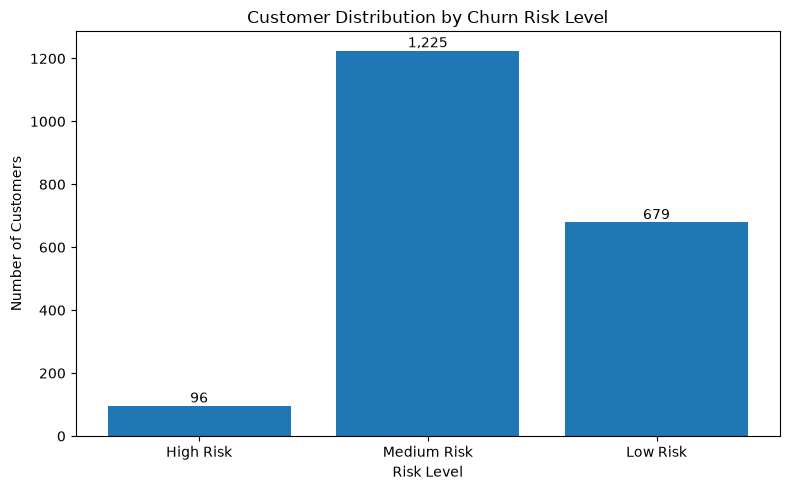

In [42]:
plt.figure(figsize=(8, 5))

plt.bar(
    risk_summary["risk_level"],
    risk_summary["customer_count"]
)

plt.title("Customer Distribution by Churn Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")

for i, value in enumerate(risk_summary["customer_count"]):
    plt.text(
        i,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## 29. Retention Priority Analysis

Churn probability menunjukkan risiko customer untuk churn, tetapi business
team juga perlu mempertimbangkan customer value.

Retention priority dibuat dengan menggabungkan churn probability dengan
customer monetary value.

Customer dengan churn risk tinggi dan monetary value tinggi dianggap lebih
penting untuk diprioritaskan karena kehilangan customer tersebut berpotensi
memberikan business impact yang lebih besar.

Analisis ini menggunakan customer pada test set agar risk score berasal dari
model yang belum digunakan untuk training.

### Priority Logic

- High Priority: High Risk + high monetary value
- Medium Priority: Medium Risk atau customer dengan moderate value
- Low Priority: Low Risk + lower monetary value

Monetary value digunakan sebagai proxy sederhana untuk customer value.

In [43]:
# Get customer behavioral features from the test set
retention_priority = customer_features.loc[
    X_test_refined.index,
    [
        "customer_id",
        "monetary",
        "frequency",
        "recency_days"
    ]
].copy()

# Add churn probability from the final model
retention_priority["churn_probability"] = churn_probability

# Add risk level
retention_priority["risk_level"] = pd.cut(
    retention_priority["churn_probability"],
    bins=[-float("inf"), 0.40, 0.70, float("inf")],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

# Define high customer value using the median monetary value
monetary_threshold = retention_priority["monetary"].median()

retention_priority["customer_value"] = np.where(
    retention_priority["monetary"] >= monetary_threshold,
    "High Value",
    "Lower Value"
)

# Define retention priority
retention_priority["priority"] = np.select(
    [
        (
            (retention_priority["risk_level"] == "High Risk")
            & (retention_priority["customer_value"] == "High Value")
        ),
        (
            (retention_priority["risk_level"] == "High Risk")
            | (retention_priority["risk_level"] == "Medium Risk")
        )
    ],
    [
        "High Priority",
        "Medium Priority"
    ],
    default="Low Priority"
)

# Sort by priority and churn probability
priority_order = {
    "High Priority": 0,
    "Medium Priority": 1,
    "Low Priority": 2
}

retention_priority["priority_order"] = (
    retention_priority["priority"].map(priority_order)
)

retention_priority = retention_priority.sort_values(
    ["priority_order", "churn_probability", "monetary"],
    ascending=[True, False, False]
).reset_index(drop=True)

retention_priority = retention_priority.drop(
    columns=["priority_order"]
)

print("Top Retention Priority Customers:")

display(
    retention_priority.head(20)
)

Top Retention Priority Customers:


,customer_id,monetary,frequency,recency_days,churn_probability,risk_level,customer_value,priority
0,C04363,717.66,5.00,176.00,0.73,High Risk,High Value,High Priority
1,C07600,451.22,3.00,249.00,0.72,High Risk,High Value,High Priority
2,C09239,637.77,2.00,234.00,0.71,High Risk,High Value,High Priority
3,C05748,452.95,1.00,725.00,0.71,High Risk,High Value,High Priority
4,C09541,"1,733.02",2.00,426.00,0.70,High Risk,High Value,High Priority
5,C01831,0.00,0.00,NaN,0.80,High Risk,Lower Value,Medium Priority
6,C02920,0.00,0.00,NaN,0.78,High Risk,Lower Value,Medium Priority
7,C05282,0.00,0.00,NaN,0.78,High Risk,Lower Value,Medium Priority
8,C06170,98.63,1.00,329.00,0.77,High Risk,Lower Value,Medium Priority
9,C03594,197.89,4.00,160.00,0.77,High Risk,Lower Value,Medium Priority


## 29. Retention Priority Analysis

Churn probability menunjukkan risiko customer untuk churn, tetapi business
team juga perlu mempertimbangkan customer value dan purchase history.

Customer yang belum pernah melakukan completed purchase tidak diperlakukan
sebagai retention target karena belum memiliki purchase history yang dapat
dipertahankan.

Customer tersebut dipisahkan sebagai `Reactivation / Acquisition`.

Untuk customer yang memiliki purchase history, retention priority dibuat
dengan menggabungkan:

- churn probability;
- monetary value;
- purchase frequency;
- recency.

### Priority Logic

- High Priority: High Risk + High Value
- Medium Priority: High Risk + Lower Value atau Medium Risk
- Low Priority: Low Risk

Customer tanpa purchase history:

- Reactivation / Acquisition

Monetary value digunakan sebagai proxy sederhana untuk customer value.

Analisis menggunakan customer pada test set agar risk score berasal dari
model yang belum digunakan untuk training.

In [44]:
# Get customer behavioral features from the test set
retention_priority = customer_features.loc[
    X_test_refined.index,
    [
        "customer_id",
        "monetary",
        "frequency",
        "recency_days"
    ]
].copy()

# Add churn probability
retention_priority["churn_probability"] = churn_probability

# Identify customers with purchase history
retention_priority["has_purchase"] = (
    retention_priority["frequency"] > 0
)

# Define risk level
retention_priority["risk_level"] = pd.cut(
    retention_priority["churn_probability"],
    bins=[-float("inf"), 0.40, 0.70, float("inf")],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

# Calculate customer value threshold only from customers with purchases
purchase_customers = retention_priority[
    retention_priority["has_purchase"]
]

monetary_threshold = purchase_customers["monetary"].median()

# Define customer value
retention_priority["customer_value"] = np.where(
    ~retention_priority["has_purchase"],
    "No Purchase",
    np.where(
        retention_priority["monetary"] >= monetary_threshold,
        "High Value",
        "Lower Value"
    )
)

# Define retention priority
retention_priority["priority"] = np.select(
    [
        ~retention_priority["has_purchase"],
        (
            (retention_priority["risk_level"] == "High Risk")
            & (retention_priority["customer_value"] == "High Value")
        ),
        (
            (retention_priority["risk_level"] == "High Risk")
            | (retention_priority["risk_level"] == "Medium Risk")
        )
    ],
    [
        "Reactivation / Acquisition",
        "High Priority",
        "Medium Priority"
    ],
    default="Low Priority"
)

# Sort priority for business use
priority_order = {
    "High Priority": 0,
    "Medium Priority": 1,
    "Low Priority": 2,
    "Reactivation / Acquisition": 3
}

retention_priority["priority_order"] = (
    retention_priority["priority"].map(priority_order)
)

retention_priority = retention_priority.sort_values(
    [
        "priority_order",
        "churn_probability",
        "monetary"
    ],
    ascending=[True, False, False]
).reset_index(drop=True)

retention_priority = retention_priority.drop(
    columns=["priority_order"]
)

print("Top Retention Priority Customers:")

display(
    retention_priority.head(20)
)

Top Retention Priority Customers:


,customer_id,monetary,frequency,recency_days,churn_probability,has_purchase,risk_level,customer_value,priority
0,C04363,717.66,5.00,176.00,0.73,True,High Risk,High Value,High Priority
1,C07600,451.22,3.00,249.00,0.72,True,High Risk,High Value,High Priority
2,C09239,637.77,2.00,234.00,0.71,True,High Risk,High Value,High Priority
3,C05748,452.95,1.00,725.00,0.71,True,High Risk,High Value,High Priority
4,C09541,"1,733.02",2.00,426.00,0.70,True,High Risk,High Value,High Priority
5,C06170,98.63,1.00,329.00,0.77,True,High Risk,Lower Value,Medium Priority
6,C03594,197.89,4.00,160.00,0.77,True,High Risk,Lower Value,Medium Priority
7,C06406,153.18,2.00,244.00,0.77,True,High Risk,Lower Value,Medium Priority
8,C03208,71.68,1.00,669.00,0.77,True,High Risk,Lower Value,Medium Priority
9,C06157,78.71,2.00,407.00,0.76,True,High Risk,Lower Value,Medium Priority


## 30. Retention Priority Distribution

Setelah customer risk dan customer value digabungkan, langkah berikutnya
adalah melihat jumlah customer pada setiap retention priority.

Distribusi ini membantu business team memperkirakan ukuran target untuk
masing-masing strategi:

- High Priority → retention intervention
- Medium Priority → early intervention / monitoring
- Low Priority → regular engagement
- Reactivation / Acquisition → activation campaign

Hasil ini merupakan decision-support output dari model, bukan rekomendasi
kausal.

In [45]:
# Count customers by retention priority
priority_distribution = (
    retention_priority["priority"]
    .value_counts()
    .reindex([
        "High Priority",
        "Medium Priority",
        "Low Priority",
        "Reactivation / Acquisition"
    ])
    .fillna(0)
    .astype(int)
)

priority_summary = pd.DataFrame({
    "priority": priority_distribution.index,
    "customer_count": priority_distribution.values
})

priority_summary["percentage"] = (
    priority_summary["customer_count"]
    / len(retention_priority)
    * 100
)

display(priority_summary)

,priority,customer_count,percentage
0,High Priority,5,0.25
1,Medium Priority,1261,63.05
2,Low Priority,679,33.95
3,Reactivation / Acquisition,55,2.75


## 31. Retention Priority Visualization

Visualisasi digunakan untuk memperlihatkan distribusi customer berdasarkan
retention priority.

Hasil ini membantu business team melihat perbedaan ukuran antara customer
yang membutuhkan retention intervention, monitoring, regular engagement,
dan acquisition/reactivation campaign.

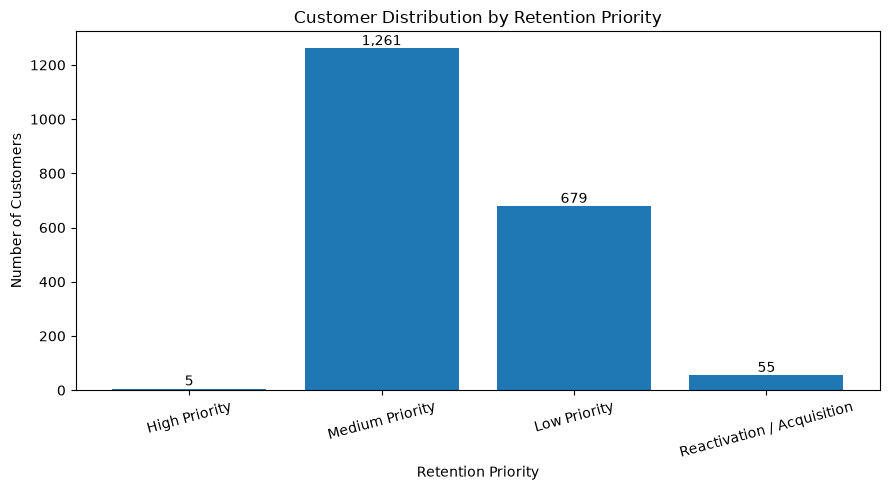

In [46]:
plt.figure(figsize=(9, 5))

plt.bar(
    priority_summary["priority"],
    priority_summary["customer_count"]
)

plt.title("Customer Distribution by Retention Priority")
plt.xlabel("Retention Priority")
plt.ylabel("Number of Customers")

for i, value in enumerate(priority_summary["customer_count"]):
    plt.text(
        i,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

## 32. Final Churn Business Summary

### Model Performance

Final model yang dipilih adalah Refined Logistic Regression.

- Accuracy: 0.60
- Precision: 0.25
- Recall: 0.66
- F1-score: 0.36
- ROC-AUC: 0.67

Recall menjadi metric utama karena business objective adalah mendeteksi
customer yang berpotensi churn.

### Key Model Findings

Behavioral features memiliki hubungan yang lebih actionable terhadap churn.

Feature dengan hubungan negatif terbesar:

- `total_sessions`: -0.30
- `frequency`: -0.26
- `avg_session_duration`: -0.12
- `tenure_days`: -0.10
- `total_quantity`: -0.09

Secara umum, customer dengan engagement dan purchase frequency yang lebih
tinggi cenderung memiliki probabilitas churn yang lebih rendah dalam dataset.

### Customer Risk Distribution

Pada test set sebanyak 2.000 customer:

- High Risk: 96 customer (4.80%)
- Medium Risk: 1.225 customer (61.25%)
- Low Risk: 679 customer (33.95%)

### Retention Priority

Setelah menggabungkan churn risk dengan customer value:

- High Priority: 5 customer (0.25%)
- Medium Priority: 1.261 customer (63.05%)
- Low Priority: 679 customer (33.95%)
- Reactivation / Acquisition: 55 customer (2.75%)

### Business Recommendations

1. Prioritaskan 5 customer High Priority untuk retention intervention.
2. Monitor customer Medium Priority sebagai early-warning group.
3. Gunakan engagement dan purchase frequency sebagai behavioral indicators.
4. Pisahkan customer tanpa purchase history dari retention campaign.
5. Gunakan model sebagai decision-support tool, bukan sebagai automated
   decision maker.

### Limitations

Dataset yang digunakan merupakan synthetic dataset.

Model menunjukkan statistical association dan tidak membuktikan causal
relationship.

Feature demographic seperti country dan gender tidak boleh langsung
diterjemahkan sebagai penyebab churn.

Model juga belum production-ready dan belum melalui external validation,
model calibration, threshold optimization, atau monitoring terhadap model
drift.